# Quick overview

## Create the simulation

In [ ]:
import numpy as np
from lucifex.fem import grid_cross_section
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz
from lucifex.viz import (
    plot_colormap, plot_contours, plot_line, get_ipynb_file_name, set_ipynb_variable,
)
from lucifex.utils.array_utils import as_indices
from crocodil.dns.theory import threshold_rayleigh
from crocodil.dns.system_b import dns_system_b, SYSTEM_B_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 80)
NY = set_ipynb_variable('NY', 80)
ANIM = set_ipynb_variable('ANIM', False)

simulation = dns_system_b(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_datetime=True,
    dir_uid=True,
)(
    Nx=NX,
    Ny=NY,
    cell='quadrilateral',
    scaling='advective',
    **SYSTEM_B_REFERENCE.replace(Da=1.0),
    dt_max=0.1,
    courant_adv=0.75,
    courant_diff=0.75,
    courant_reac=0.1,
    c_stabilization=None,
    c_limits=(0,1),
    theta_limits=(0,1),
    diagnostic=True,
)

Lx, Ly = simulation['Lx', 'Ly']
Ra, Da, epsilon, Le, sr = (
    float(i) for i in simulation['Ra', 'Da', 'epsilon', 'Le', 'sr']
)

Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra = {Ra} , Ra_thresh = {Ra_thresh}")

Ra = 1000.0 , Ra_thresh = 1800.0


## Run the simulation

In [2]:
n_stop = set_ipynb_variable('N_STOP', 50)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

write(simulation.parameters, simulation.parameter_file, simulation.dir_path, mode='w')
run(simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
if WRITE: xdmf_to_npz(simulation, delete_xdmf=False)

s, c, theta, psi, u = simulation['s', 'c', 'theta', 'psi', 'u']
mC, mD = simulation['mC', 'mD']
uRMS = simulation['uRMS']
sMinMax, cMinMax, thetaMinMax = simulation['sMinMax', 'cMinMax', 'thetaMinMax']

sMin, sMax = sMinMax.split()
cMin, cMax = cMinMax.split()
thetaMin, thetaMax = thetaMinMax.split()

100%|██████████| 50/50 [01:16<00:00,  1.53s/it]


## Physical diagnostics

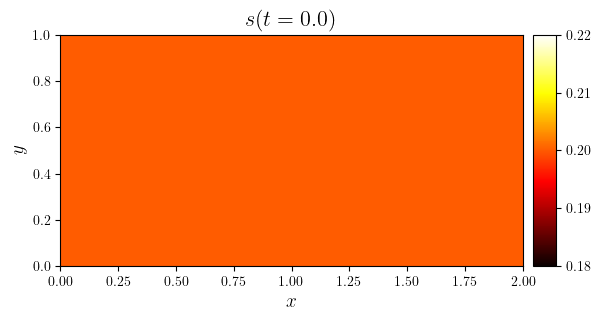

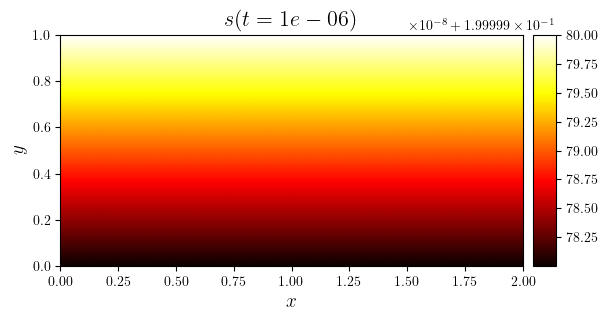

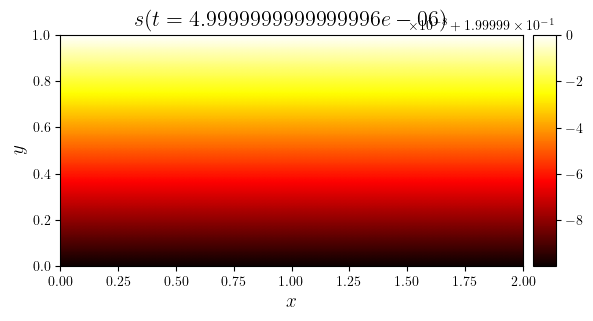

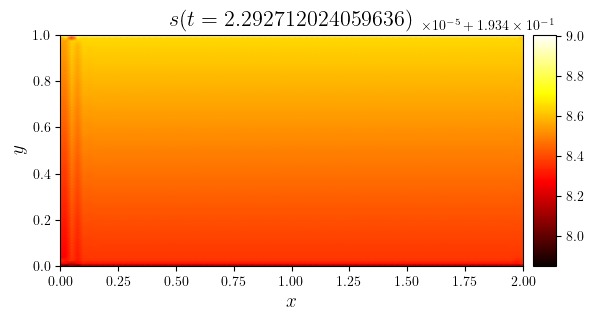

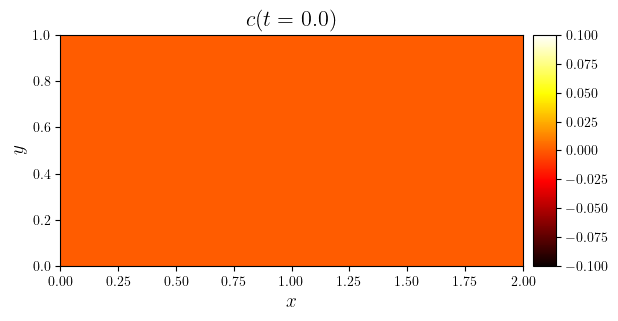

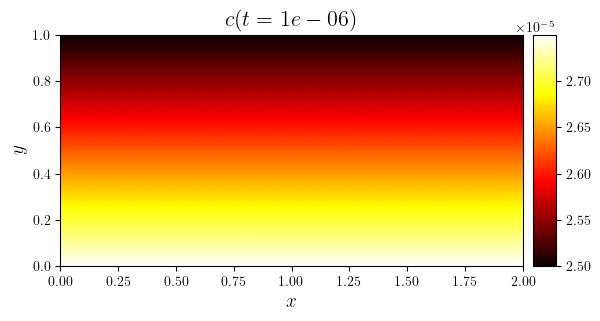

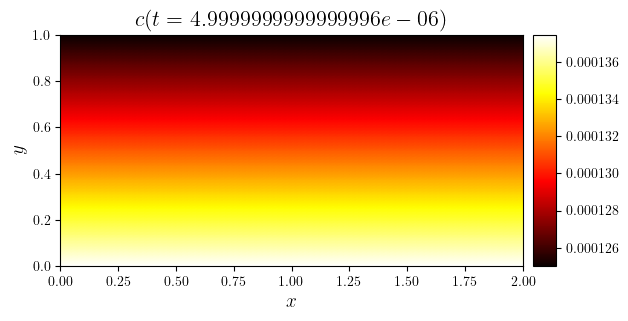

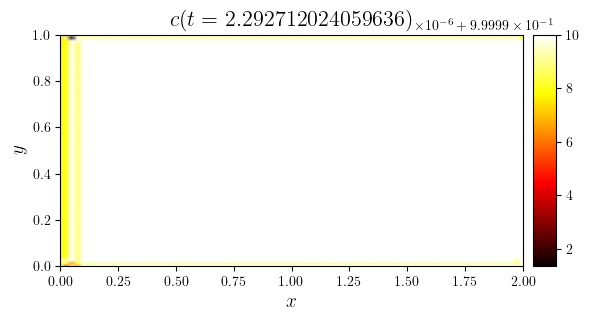

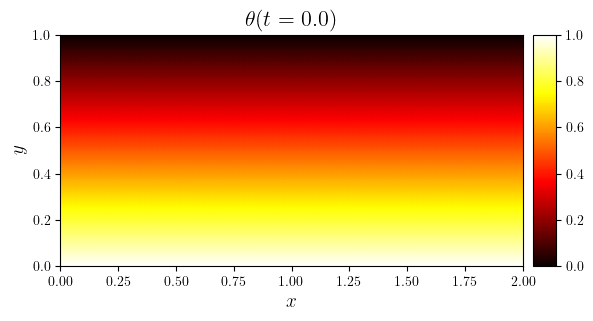

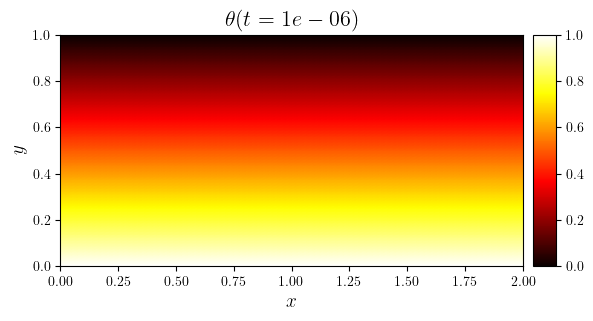

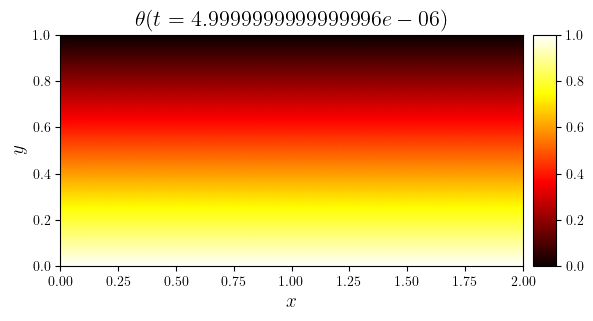

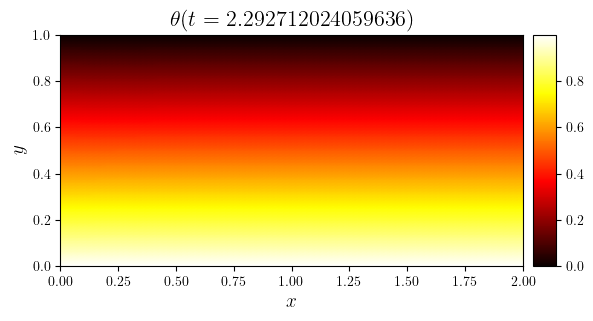

In [3]:
time_indices = as_indices(c.time_series, (0, 1, 5, -1), fraction=True)
series_triplet = (s, c, theta)
tex_triplet = ('s', 'c', '\\theta')

for q, q_tex in zip(series_triplet, tex_triplet):
    for i in time_indices:
        fig, ax = plot_colormap(q.series[i], title=f'${q_tex}(t={q.time_series[i]})$')

## Numerical diagnostics

### Velocity norms

(<Figure size 640x480 with 1 Axes>, <Axes: >)

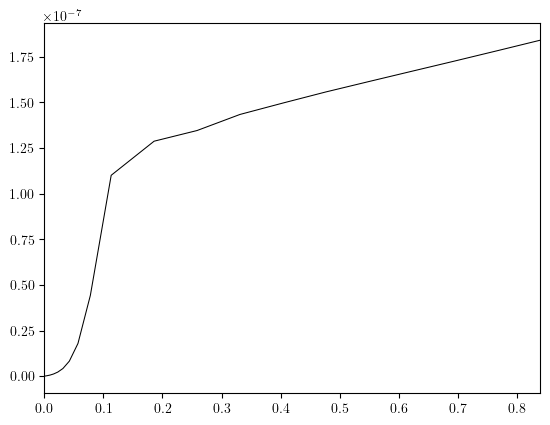

In [8]:
plot_line((uRMS.time_series, uRMS.value_series))

## Saturation, concentration and temperature limits

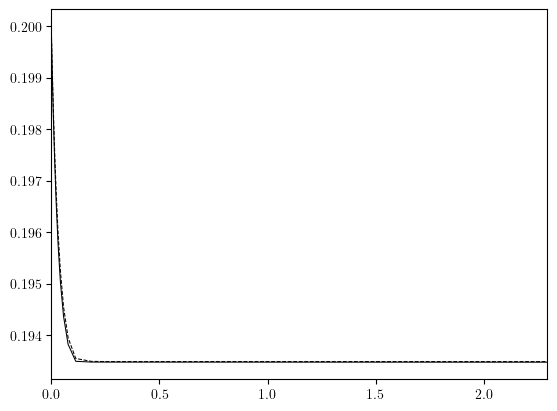

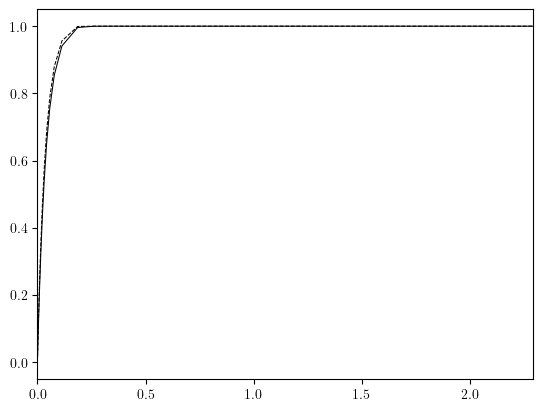

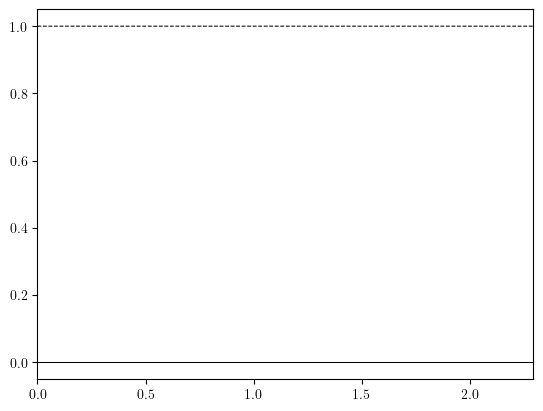

In [4]:
for minmax in (sMinMax, cMinMax, thetaMinMax):
    plot_line((minmax.time_series, minmax.value_series), cyc='black')